In [ ]:
import importlib, main
importlib.reload(main)

from main import build_config
from Trainers.CUTtrain import CUTTrainer

cfg = { 
       "data": {
            "low_res_dir": "Data/Low_resolution/CFRP_60_low",
            "high_res_dir": "Data/High_resolution/CFRP_60_high",
            "paired": False,
        },
        "training": {
            "batch_size": 4,      # smaller batch
            "num_epochs": 50,
            "lr": 2e-4,
            "beta1": 0.5,
            "beta2": 0.999,
            "num_workers": 0,     # safer/faster on Windows
        },
        "model": {
            "input_nc": 3,
            "output_nc": 3,
            "ngf": 32,            # was 64
            "ndf": 32,            # was 64
        },
        "cut": {
            "lambda_GAN": 1.0,
            "lambda_NCE": 1.0,    # unused in simplified mode
            "lambda_idt": 0.5,
            "num_patches": 64,    # doesn’t matter much if simplified
            "nce_layers": "4,8",
            "nce_T": 0.07,
            "use_simplified": False,    # KEY: turns off heavy NCE
            "checkpoints_dir": "./checkpoints",
            "name": "cut_experiment_fast",
            "direction": "AtoB",
        }
}

trainer = CUTTrainer(cfg)
print("model.use_simplified:", trainer.model.use_simplified)
print("G device:", next(trainer.model.netG.parameters()).device)
print("real_A device (after one batch):")
batch = next(iter(trainer.dataloader))
trainer.model.set_input({
    "A": batch["low_res"].to(trainer.model.device),
    "B": batch["high_res"].to(trainer.model.device),
    "A_paths": batch["low_path"],
    "B_paths": batch["high_path"],
})
print(trainer.model.real_A.device)


cfg['cut']: {'lambda_GAN': 1.0, 'lambda_NCE': 1.0, 'lambda_idt': 0.5, 'num_patches': 64, 'nce_layers': '4,8', 'nce_T': 0.07, 'use_simplified': False, 'checkpoints_dir': './checkpoints', 'name': 'cut_experiment_fast', 'direction': 'AtoB'}
Using device: cuda
model.use_simplified: False
G device: cuda:0
real_A device (after one batch):
cuda:0


In [2]:
trainer.train()

Epoch [1/50] G_loss: 7.2539, D_loss: 1.2738
Epoch [2/50] G_loss: 6.9301, D_loss: 1.2791
Epoch [3/50] G_loss: 5.7201, D_loss: 0.3778
Epoch [4/50] G_loss: 7.2728, D_loss: 1.3346
Epoch [5/50] G_loss: 5.6181, D_loss: 0.4941
Epoch [6/50] G_loss: 5.4515, D_loss: 0.2469
Epoch [7/50] G_loss: 6.3705, D_loss: 1.6895
Epoch [8/50] G_loss: 5.3398, D_loss: 0.0909
Epoch [9/50] G_loss: 5.3354, D_loss: 0.1645
Epoch [10/50] G_loss: 5.5351, D_loss: 0.3448
Epoch [11/50] G_loss: 5.4086, D_loss: 0.3463
Epoch [12/50] G_loss: 6.0350, D_loss: 0.9131
Epoch [13/50] G_loss: 5.2181, D_loss: 0.1644
Epoch [14/50] G_loss: 5.3769, D_loss: 0.2772
Epoch [15/50] G_loss: 5.3251, D_loss: 0.2575
Epoch [16/50] G_loss: 5.2785, D_loss: 0.1368
Epoch [17/50] G_loss: 5.2979, D_loss: 0.1438
Epoch [18/50] G_loss: 5.2729, D_loss: 0.1324
Epoch [19/50] G_loss: 5.3176, D_loss: 0.1624
Epoch [20/50] G_loss: 5.0991, D_loss: 0.1965
Epoch [21/50] G_loss: 5.2566, D_loss: 0.1584
Epoch [22/50] G_loss: 5.2850, D_loss: 0.1783
Epoch [23/50] G_los

In [3]:
trainer.model.eval()
batch = next(iter(trainer.dataloader))
trainer.model.set_input({
    "A": batch["low_res"].to(trainer.model.device),
    "B": batch["high_res"].to(trainer.model.device),
    "A_paths": batch["low_path"],
    "B_paths": batch["high_path"],
})
trainer.model.test()
visuals = trainer.model.get_current_visuals()

In [46]:
import torch
import matplotlib.pyplot as plt

def tensor_to_image(t):
    # t: [B, C, H, W] from model
    img = t[0].detach().cpu()          # first in batch
    img = (img * 0.5) + 0.5            # [-1,1] -> [0,1]
    if img.shape[0] == 1:
        img = img.squeeze(0)           # [1,H,W] -> [H,W] for grayscale
        cmap = "gray"
    else:
        img = img.permute(1, 2, 0)     # [C,H,W] -> [H,W,C]
        cmap = None
    return img, cmap

visuals = trainer.model.get_current_visuals()

real_A_img, cmap_A = tensor_to_image(visuals["real_A"])
fake_B_img, cmap_B = tensor_to_image(visuals["fake_B"])
real_B_img, cmap_Br = tensor_to_image(visuals["real_B"])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(real_A_img, cmap=cmap_A); plt.title("Real A"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(fake_B_img, cmap=cmap_B); plt.title("Fake B"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(real_B_img, cmap=cmap_Br); plt.title("Real B"); plt.axis("off")
plt.show()


AttributeError: 'WGANModel' object has no attribute 'get_current_visuals'

In [16]:
from Trainers.WGANtrain import WGANTrainer

config = {
    "data": {
        "low_res_dir": "Data/Low_resolution/CFRP_60_low",
        "high_res_dir": "Data/High_resolution/CFRP_60_high",
        "paired": False,
    },
    "training": {
        "batch_size": 4,
        "num_epochs": 50,
        "lr": 1e-4,
        "beta1": 0.5,
        "beta2": 0.9,
        "num_workers": 0,
    },
    "model": {
        "input_nc": 3,
        "output_nc": 3,
        "ngf": 32,
        "ndf": 32,
    },
    "wgan": {
        "lambda_L1": 10.0,
        "lambda_gp": 10.0,
        "n_critic": 5,
        # "gpu_ids": [0],
    },
}

trainer = WGANTrainer(config)
trainer.train()


Using device: cuda
Starting WGAN-GP training...
Epoch [1/50]
Epoch [1/50] G: 18.5284 (adv 12.1099, L1 6.4185), D: -28.4638, GP: 0.0806
Epoch [2/50]
Epoch [2/50] G: 26.2051 (adv 20.6015, L1 5.6037), D: -44.1091, GP: 0.1085
Epoch [3/50]
Epoch [3/50] G: 20.4874 (adv 15.1199, L1 5.3676), D: -48.7711, GP: 1.2214
Epoch [4/50]
Epoch [4/50] G: 35.8271 (adv 30.7194, L1 5.1077), D: -71.1220, GP: 0.1303
Epoch [5/50]
Epoch [5/50] G: 45.9851 (adv 41.1142, L1 4.8710), D: -92.7318, GP: 0.0676
Epoch [6/50]
Epoch [6/50] G: 51.6590 (adv 46.9303, L1 4.7287), D: -107.7785, GP: 0.0959
Epoch [7/50]
Epoch [7/50] G: 60.7108 (adv 55.7547, L1 4.9561), D: -113.1793, GP: 1.8514
Epoch [8/50]
Epoch [8/50] G: 64.2346 (adv 59.5859, L1 4.6486), D: -128.2352, GP: 1.0484
Epoch [9/50]
Epoch [9/50] G: 76.6553 (adv 72.2316, L1 4.4237), D: -149.3975, GP: 0.2848
Epoch [10/50]
Epoch [10/50] G: 80.6200 (adv 76.4315, L1 4.1886), D: -169.5799, GP: 0.3659
Epoch [11/50]
Epoch [11/50] G: 87.0587 (adv 82.8869, L1 4.1717), D: -169.28

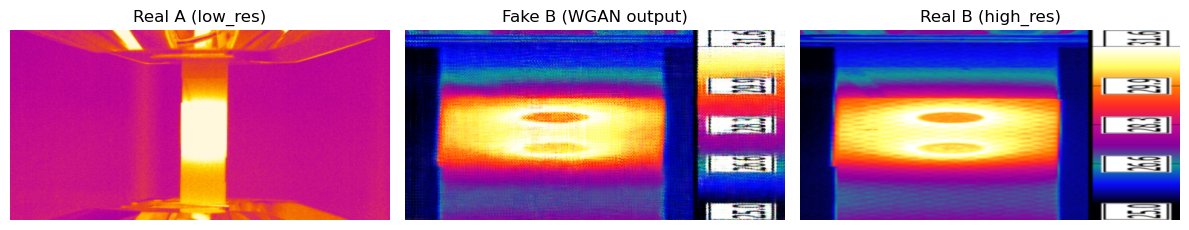

In [45]:
import torch
import matplotlib.pyplot as plt

def tensor_to_image(t):
    # t: [B, C, H, W] in [-1,1]
    img = t[0].detach().cpu()
    img = (img * 0.5) + 0.5          # [-1,1] -> [0,1]
    if img.shape[0] == 1:
        img = img.squeeze(0)         # [1,H,W] -> [H,W]
        cmap = "gray"
    else:
        img = img.permute(1, 2, 0)   # [C,H,W] -> [H,W,C]
        cmap = None
    return img, cmap

# switch to eval mode
trainer.model.eval()

# get one batch
batch = next(iter(trainer.dataloader))
trainer.model.set_input(batch)

with torch.no_grad():
    trainer.model.forward_G()
    real_A = trainer.model.real_A
    fake_B = trainer.model.fake_B
    real_B = trainer.model.real_B

real_A_img, cmap_A = tensor_to_image(real_A)
fake_B_img, cmap_F = tensor_to_image(fake_B)
real_B_img, cmap_B = tensor_to_image(real_B)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(real_A_img, cmap=cmap_A)
plt.title("Real A (low_res)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(fake_B_img, cmap=cmap_F)
plt.title("Fake B (WGAN output)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(real_B_img, cmap=cmap_B)
plt.title("Real B (high_res)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
from Trainers.SRtrain import SRTrainer

config = {
    "data": {
        "hr_dir": "Data/High_resolution/CFRP_60_high",
        "hr_size": (256, 512),
        "scale_factor": 4,
    },
    "training": {
        "batch_size": 4,
        "num_epochs": 50,
        "lr": 1e-4,
        "beta1": 0.9,
        "beta2": 0.999,
        "num_workers": 0,
    },
    "model": {
        "input_nc": 3,
        "output_nc": 3,
        "ngf": 32,
    },
}

trainer = SRTrainer(config)
trainer.train()


Using device: cuda
Starting SR training...
Epoch [1/50]
Epoch [1/50] L1: 0.2476
Epoch [2/50]
Epoch [2/50] L1: 0.1354
Epoch [3/50]
Epoch [3/50] L1: 0.1080
Epoch [4/50]
Epoch [4/50] L1: 0.0974
Epoch [5/50]
Epoch [5/50] L1: 0.0902
Epoch [6/50]
Epoch [6/50] L1: 0.0861
Epoch [7/50]
Epoch [7/50] L1: 0.0826
Epoch [8/50]
Epoch [8/50] L1: 0.0785
Epoch [9/50]
Epoch [9/50] L1: 0.0761
Epoch [10/50]
Epoch [10/50] L1: 0.0736
Epoch [11/50]
Epoch [11/50] L1: 0.0717
Epoch [12/50]
Epoch [12/50] L1: 0.0712
Epoch [13/50]
Epoch [13/50] L1: 0.0691
Epoch [14/50]
Epoch [14/50] L1: 0.0672
Epoch [15/50]
Epoch [15/50] L1: 0.0651
Epoch [16/50]
Epoch [16/50] L1: 0.0636
Epoch [17/50]
Epoch [17/50] L1: 0.0630
Epoch [18/50]
Epoch [18/50] L1: 0.0620
Epoch [19/50]
Epoch [19/50] L1: 0.0595
Epoch [20/50]
Epoch [20/50] L1: 0.0584
Epoch [21/50]
Epoch [21/50] L1: 0.0570
Epoch [22/50]
Epoch [22/50] L1: 0.0557
Epoch [23/50]
Epoch [23/50] L1: 0.0559
Epoch [24/50]
Epoch [24/50] L1: 0.0554
Epoch [25/50]
Epoch [25/50] L1: 0.0536


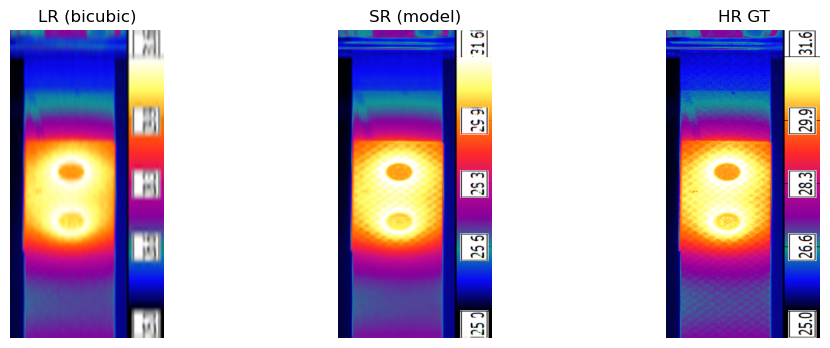

In [7]:
import matplotlib.pyplot as plt
import torch

def tensor_to_image(t):
    img = t[0].detach().cpu()
    img = (img * 0.5) + 0.5
    if img.shape[0] == 1:
        img = img.squeeze(0)
        cmap = "gray"
    else:
        img = img.permute(1, 2, 0)
        cmap = None
    return img, cmap

batch = next(iter(trainer.dataloader))
trainer.model.eval()
trainer.model.set_input(batch)
with torch.no_grad():
    fake_hr = trainer.model.netG(batch["lr"].to(trainer.model.device))

lr_img, cmap_lr = tensor_to_image(batch["lr"])
fake_img, cmap_f = tensor_to_image(fake_hr)
hr_img, cmap_hr = tensor_to_image(batch["hr"])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(lr_img, cmap=cmap_lr); plt.title("LR (bicubic)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(fake_img, cmap=cmap_f); plt.title("SR (model)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(hr_img, cmap=cmap_hr); plt.title("HR GT"); plt.axis("off")
plt.show()


Testing on: Data\Low_resolution\CFRP_60_low\Record_2025-11-11_10-42-17.tiff


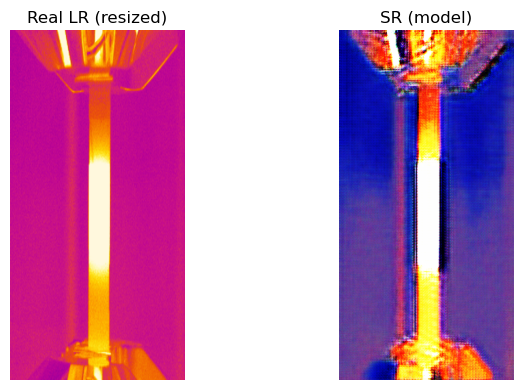

In [15]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torchvision import transforms

# match the size you trained on
HR_SIZE = (256, 512)

to_tensor = transforms.ToTensor()
normalize = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])

def preprocess_real_lr(img_path):
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize(HR_SIZE, Image.BICUBIC)
    t = normalize(to_tensor(img_resized)).unsqueeze(0).to(device)  # [1,3,H,W]
    return img_resized, t

def tensor_to_img(t):
    t = t[0].detach().cpu()
    t = (t * 0.5) + 0.5
    if t.shape[0] == 1:
        return t.squeeze(0), "gray"
    else:
        return t.permute(1, 2, 0), None

sr_model = trainer.model   # assumes SRTrainer already run
sr_model.eval()
device = next(sr_model.netG.parameters()).device

# pick a low-res image
low_dir = Path("Data/Low_resolution/CFRP_60_low")
test_path = sorted(low_dir.glob("*"))[0]  # choose one file
print("Testing on:", test_path)

lr_pil, lr_tensor = preprocess_real_lr(test_path)
with torch.no_grad():
    sr_tensor = sr_model.netG(lr_tensor)

lr_img, cmap_lr = tensor_to_img(lr_tensor)
sr_img, cmap_sr = tensor_to_img(sr_tensor)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(lr_img, cmap=cmap_lr); plt.title("Real LR (resized)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(sr_img, cmap=cmap_sr); plt.title("SR (model)"); plt.axis("off")
plt.tight_layout(); plt.show()
